<a href="https://colab.research.google.com/github/calicartels/Interpretable_ML/blob/main/Assignment_3_Interpretable_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.6/29.6 MB 22.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Cloning into 'Interpretable_ML'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 177.98 KiB | 2.17 MiB/s, done.
Resolving deltas: 100% (4/4), done.


### 1. Importing Libraries and Datasets

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression,LogisticRegression, LassoCV
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.stattools import durbin_watson
from pygam import LogisticGAM




import scipy.stats as stats


In [6]:
df = pd.read_csv("Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2. EDA

In [7]:
# getting some basic information about the dataset, by checking the column types and count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# describing the variables across various statistical measures
df.describe(include = "all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [9]:
# doing another round of this, but without categorical variables because the last output was too verbose
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# checking for duplicate entries in the dataset
df.duplicated().sum()

# result : no duplicate values

0

In [11]:
# checking for null values in the dataset

df.isnull().sum()

# result: no null values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3. Visualization

#### 3.1 Basic Viz

/var/folders/sv/mmjw0hq12dq259sn6xvpn55w0000gn/T/ipykernel_73761/1786092561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette="Accent")


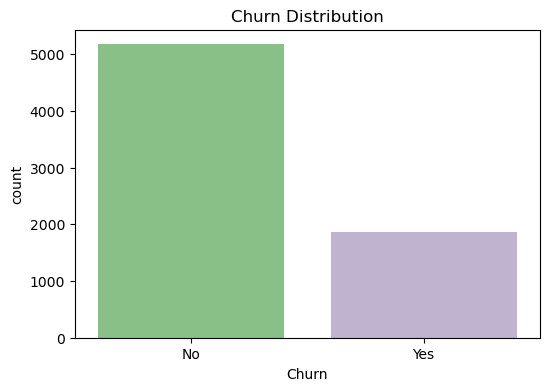

In [12]:
# Churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette="Accent")
plt.title('Churn Distribution')
plt.show()

# result : pretty straightforward, a lot of people stay with the company, but a considerable amount also leave it for a competitor.

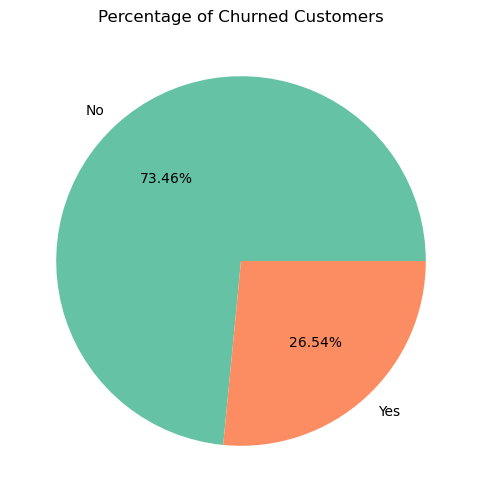

In [13]:
# Plot pie chart


palette = sns.color_palette("Set2")
gb = df.groupby("Churn").agg({"Churn": "count"})
plt.figure(figsize=(6, 6))
plt.pie(gb["Churn"], labels=gb.index, autopct="%1.2f%%", colors=palette)
plt.title("Percentage of Churned Customers", fontsize=12)
plt.show()

# result : visualizing in percentage

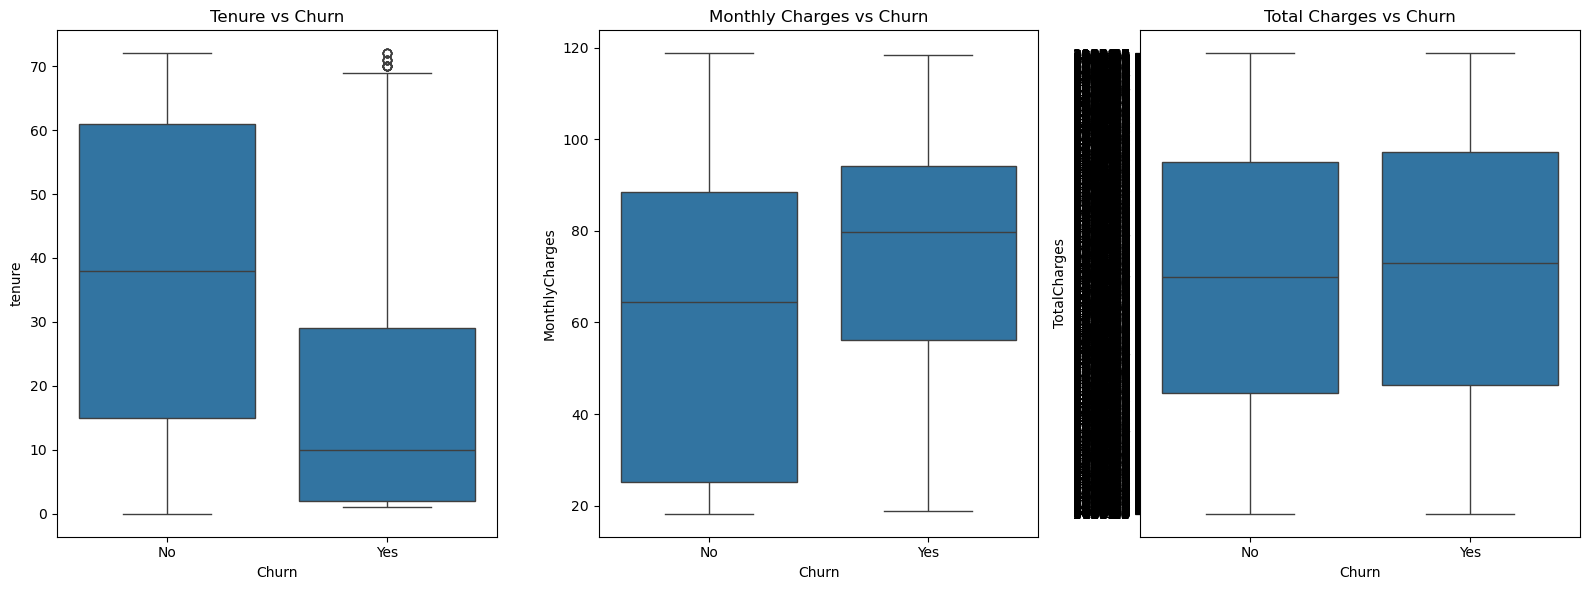

In [14]:
# Box plot for tenure, MonthlyCharges, and TotalCharges with respect to Churn


plt.figure(figsize=(16, 6))

# Tenure
plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')

# MonthlyCharges
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')

# TotalCharges
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('Total Charges vs Churn')

plt.tight_layout()
plt.show()




result :

 1. From the first plot, I can see that the those who churn do it within the first 30 or so months, excluding a couple of outliers.
  It's interesting to see an overlap betweeen the first quartile of the "No churn" and the third quartile of the "Yes Churn" column.
 The company should definitely look into why there are difference between people who stay for the same amount of time.

 2. From the second plot we can see that people on average being charged more tend to leave the company. Might be worth to check the socio-economic
  and provide targeted offers.

 3. The third plot as a lott of outliers in the "Yes churn" column, which is quite interesting. but on a very high level observation, the plot is pretty
   self-explanatory in the sense that people who leave early have lower charges.

### 4. Encoding variables

In [15]:
# 1 . Lets drop the customerID because it has no intrinsic value as such:
df = df.drop('customerID', axis=1)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [16]:

# 1. Label Encoding and One-Hot Encoding
label_encoder = LabelEncoder()

# Converting 'TotalCharges' to numeric, coercing errors to NaN, then fill NaNs with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Converting 'Churn' to binary values (0 for 'No', 1 for 'Yes')
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Converting binary categorical features using Label Encoding
binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                   'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

for feature in binary_features:
    df[feature] = label_encoder.fit_transform(df[feature])

# Converting multi-class categorical features using One-Hot Encoding
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

# 2. Normalization of numerical features
scaler = StandardScaler()
numerical_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Fit and transform the numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print(df.info())
print("\nSample of normalized numerical features:")
print(df[numerical_features].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   float64
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   float64
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

## I) Linear Regression


### 5 Feature Selection and Assumption Testing

 Before we dive any deeper into the visualizations and checking the relationships, we should perform feature selection so that we dont redundantly work with all available variables

In [17]:
# 1. Lets start with a correlation analysis, with our target variable being "churn"

corr_with_target = df.corr()['Churn'].sort_values(ascending=False)
print(corr_with_target)



Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
MultipleLines                            0.038037
PhoneService                             0.011942
gender                                  -0.008612
StreamingTV                             -0.036581
StreamingMovies                         -0.038492
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
Contract_One year                       -0.177820
DeviceProtection                        -0.178134
OnlineBackup                            -0.195525
TotalCharges                            -0.198324
InternetService_No                      -0.227890


correlation works by checking if the variables are directly or indirectly proportional to the target variable.

In terms of this problem statement:

* Positive Correlation: Values above 0 indicate a positive relationship. As these features increase, the likelihood of Churn increases.

* Negative Correlation: Values below 0 indicate a negative relationship. As these features increase, the likelihood of Churn decreases.

Some features show very low correlation with Churn:

	•	gender (-0.009)
	•	PhoneService (0.012)
	•	MultipleLines (0.038)

These features might not have a significant impact on churn based on this correlation analysis.


Highly Correlated Features:

	•	Positive: InternetService_Fiber optic, PaymentMethod_Electronic check
	•	Negative: Contract_Two year, tenure

These features are pretty important and directly influence the model.

#### 5.1 Linearity

Linear regression models are based on the idea that there is a straight-line relationship between the independent variables  X1, X2, …, Xn  and the predicted value of the target variable  Y . This relationship is described by the equation:

 $$\hat{Y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + … + \beta_n X_n $$

In this equation, we assume:
	Each feature has a constant effect on the target variable.
	Changes in the features  X_i  result in proportional changes in the target.

This straight-line (linear) assumption is crucial to how the model makes predictions. The coefficients represent the slope of the line and indicate the impact of each feature on the target variable.

Therefore Linearity is assumed

####5.2 Checking for Independence and Multicollinearity

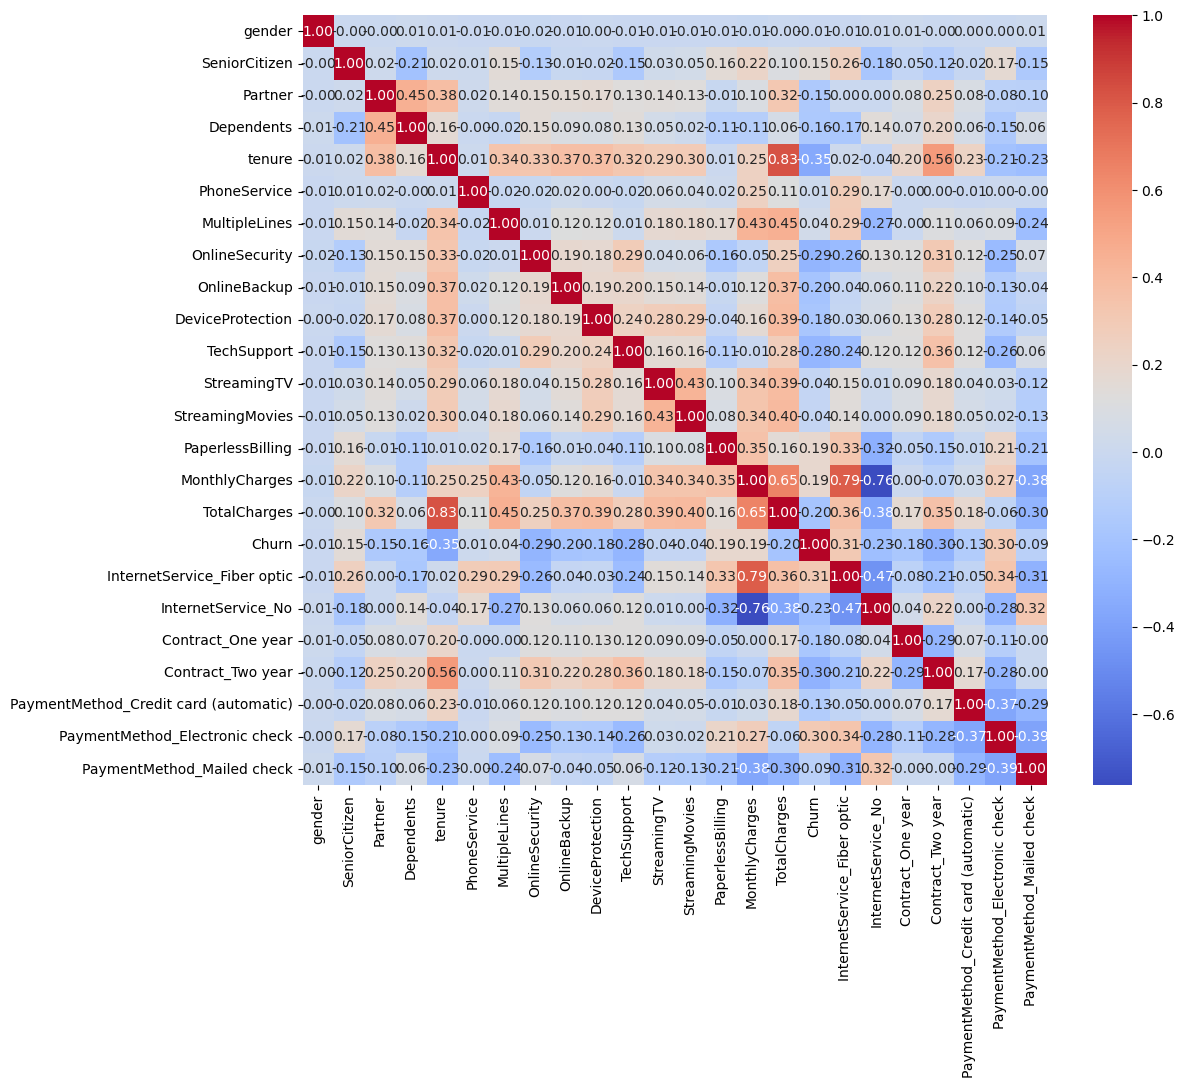

In [18]:
# 2. Lets proceed with a correlation matrix:
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# result: Shows a quick overview of the relationships between multiple variables all at once.

From this matrix above we can see that the features which are correlated to each other are:

* Tenure and Total Charges
* InternetService_No and Monthly Charges
* InternetService_Fiber optic and MonthlyCharges
* TotalCharges and MonthlyCharges
* Contract_Two year and tenure

and None of the features have a complete dependance on each other hence proving Independance



---


`**before we move any further, the rest of the assumptions can be tested only after fitting the data into the model.**`

---


###6 Feature Selection using RFE, modelling and evaluation


In [19]:


X = df.drop(columns=['Churn'])  # Features
y = df['Churn']  # Target variable

# Spliting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating a linear regression model
linear_model = LinearRegression()

# Using RFE (Recursive Feature Elimination) to select the top n features:

n_features_to_select = 13  # Choose the number of features to select,
# I landed on 13 through a trial and error process and it preserved most of the accuracy.

rfe = RFE(estimator=linear_model, n_features_to_select=n_features_to_select)

# Fitting RFE on training data
rfe.fit(X_train, y_train)

# Getting the selected features (True for selected features, False for unselected)
selected_features = rfe.support_

# Listing of selected feature names
pruned_features = X_train.columns[selected_features]
print("Selected features:", pruned_features)

# Pruning the features based on the results
X_train_pruned = X_train[pruned_features]
X_test_pruned = X_test[pruned_features]

# Fitting linear regression model with pruned features
linear_model.fit(X_train_pruned, y_train)

# Making predictions on the test set (regression output)
y_pred_continuous = linear_model.predict(X_test_pruned)

# Converting continuous predictions to binary (classification) using a threshold (0.5)
y_pred = (y_pred_continuous >= 0.5).astype(int)

# Evaluating the model with classification metrics
f1_li = f1_score(y_test, y_pred)
accuracy_li = accuracy_score(y_test, y_pred)
precision_li = precision_score(y_test, y_pred)
recall_li = recall_score(y_test, y_pred)

print(f'Accuracy: {accuracy_li}')
print(f'Precision: {precision_li}')
print(f'Recall: {recall_li}')
print(f'F1 Score: {f1_li}')

Selected features: Index(['tenure', 'PhoneService', 'MultipleLines', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Electronic check'],
      dtype='object')
Accuracy: 0.8176011355571328
Precision: 0.6858974358974359
Recall: 0.5737265415549598
F1 Score: 0.6248175182481752


**Take Aways**

1. Accuracy (81.7%):

	•	Average, but honestly not necessarily reliable in this case. Accuracy can be misleading, since this is an imbalanced dataset (More customers stay than leave). Here it might mean that the model is predicting the customers who stay correctly while failing to capture the customers who churn.

2. Precision (68.5%):

	•	Precision measures how many of the predicted “churns” are actually churners. It’s correct about 68.5% of the time. This is moderate, but not great for a churn prediction model.

3. Recall (57.3%):

	•	Poor, a recall of 57.3% means the model is missing over half of the actual churners, which is problematic because the goal of churn prediction is to identify those customers at risk of leaving.

4. F1 Score (62.4%):

	•	At 62.4%, it suggests that the model has a moderate trade-off between precision and recall, but neither is particularly strong. Given that the F1 score is relatively low compared to accuracy, this indicates the model is having trouble balancing precision and recall.

#### 6.1 Model Coefficient analysis:



In [20]:
coefficients = linear_model.coef_

import pandas as pd
feature_importances = pd.DataFrame({
    'Feature': X_train_pruned.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importances)

                           Feature  Coefficient
8      InternetService_Fiber optic     0.347202
1                     PhoneService     0.129168
12  PaymentMethod_Electronic check     0.077325
4                  StreamingMovies     0.066541
3                      StreamingTV     0.055674
5                 PaperlessBilling     0.047954
2                    MultipleLines     0.042442
0                           tenure    -0.044162
11               Contract_Two year    -0.093447
7                     TotalCharges    -0.094997
10               Contract_One year    -0.113600
6                   MonthlyCharges    -0.196272
9               InternetService_No    -0.423436



1.	Positive Coefficients:

•	InternetService_Fiber optic (0.347202): Customers with Fiber optic internet service are associated with a higher likelihood of churn. This feature has the highest positive coefficient, indicating it’s a strong predictor of churn.

•	PhoneService (0.129168):

Having phone service slightly increases the likelihood of churn, though the effect is relatively modest compared to other features.

•	PaymentMethod_Electronic check (0.077325):

Using electronic check as a payment method is associated with a small increase in churn likelihood.

•	StreamingMovies (0.066541):

Subscribing to streaming movies is positively related to churn, but the impact is small.

•	StreamingTV (0.055674):

Similar to streaming movies, streaming TV has a slight positive effect on churn.

•	PaperlessBilling (0.047954):

Opting for paperless billing has a small positive effect on churn.

•	MultipleLines (0.042442):

Having multiple lines slightly increases the churn probability, but the effect is minimal.

2.	Negative Coefficients:


•	tenure (-0.044162):

Longer tenure is associated with a slightly lower likelihood of churn. This is expected as customers who stay longer are generally less likely to churn.

•	Contract_Two year (-0.093447):

Having a two-year contract decreases the likelihood of churn more than a one-year contract, as customers with longer commitments are less likely to leave.

•	TotalCharges (-0.094997):

Higher total charges are negatively associated with churn. This might indicate that customers who have spent more are less likely to leave.

•	Contract_One year (-0.113600):

 A one-year contract reduces the likelihood of churn compared to having no contract.

•	MonthlyCharges (-0.196272):

Higher monthly charges are strongly negatively associated with churn, suggesting that more expensive plans are less likely to result in churn.

•	InternetService_No (-0.423436):

Not having internet service is strongly negatively associated with churn. This indicates that customers without internet service are significantly less likely to churn.


### 7  Testing Assumptions for Linear regression: (contd..)

#### 7.1 Homoscedasticity

To test for homoscedasticity, we can you a Residuals vs. Fitted values plot. If the model is homoscedastic, the residuals will scatter randomly around zero with no visible pattern.


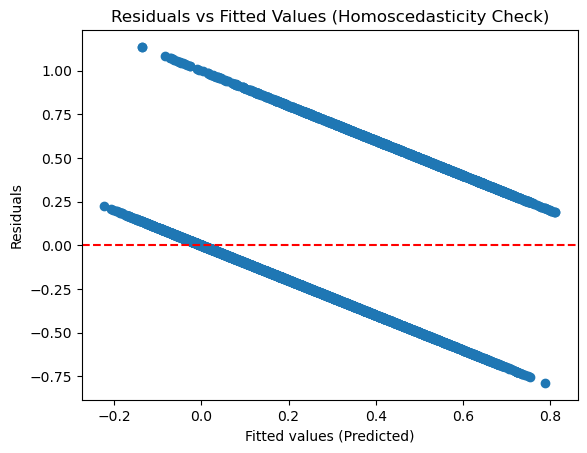

In [21]:

# Predictions for training data
y_train_pred = linear_model.predict(X_train_pruned)

# Residuals (errors) = actual values - predicted values
residuals = y_train - y_train_pred

# Plot Residuals vs. Fitted values
plt.scatter(y_train_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted values (Predicted)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Homoscedasticity Check)')
plt.show()

This plot shows us that we have a probelem with homoscedasticity.

1. The residuals are not randomly scattered around the zero line. Instead, there's a clear downward trend as the fitted values increase.

2. The spread of residuals is wider on the left side of the plot and narrows as you move to the right which is a sign of heteroscedasticity.

3. The residuals are not symmetrically distributed above and below the zero line, especially for higher fitted values.

4. The variance of residuals appears to decrease as the fitted values increase, which violates the assumption of constant variance.


**We can try to fix this using weighted least squares**

#### 7.2 Normality

We can use the Q-Q plot to test for QQ plot and histogram of the residuals. A QQ plot compares the distribution of residuals with a normal distribution.

Normality is essentially done to check if the residuals follow a normal distribution.

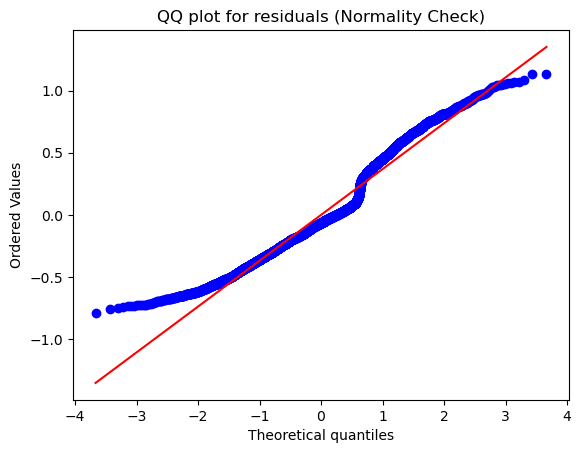

In [22]:

# QQ plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ plot for residuals (Normality Check)')
plt.show()


Result : While the data isnt exactly normally distributed, we can find that there are outliers, since it doesnt follow the line completely.

#### 7.3 No Autocorrelation

We can use something called the durbin-Watson test to determine whether there is anytype of autocorrelation or not.

The values range between 0 and 4. A value close to 2 means no autocorrelation. Values closer to 0 indicate positive autocorrelation, and values closer to 4 indicate negative autocorrelation.

In [23]:
dw = durbin_watson(residuals)
print(f'Durbin-Watson statistic: {dw}')

Durbin-Watson statistic: 1.9955814659746973


Result: As expected, there are no autocorrelations between the residuals, and the test proves the same since it is closer to 2

## II) Logistic Regression

Lets test the data on Logistic regression

In [24]:


# Define Features and Target variable
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using LassoCV for feature selection
lasso = LassoCV(cv=10).fit(X_train, y_train)

# Select the features with non-zero coefficients from Lasso
selected_features = np.where(lasso.coef_ != 0)[0]  # Indices of selected features
pruned_features = X_train.columns[selected_features]

print("Selected features:", pruned_features)

# Pruning the features based on the Lasso results
X_train_pruned = X_train[pruned_features]
X_test_pruned = X_test[pruned_features]

# Now fitting Logistic Regression with pruned features
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_pruned, y_train)

# Making predictions on the test set
y_pred = logistic_model.predict(X_test_pruned)

# Evaluating the model with classification metrics
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

Selected features: Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'TotalCharges', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')
Accuracy: 0.8218594748048261
Precision: 0.6871165644171779
Recall: 0.6005361930294906
F1 Score: 0.6409155937052933


**Takeaways**

When compared to linear regression, the improvement in evaluation metrics is ever so small.

One could say both these models perform almost the same.

#### 1.1 Checking coefficients of this logistic regression :

In [25]:
coefficients = logistic_model.coef_[0]

import pandas as pd
feature_importances = pd.DataFrame({
    'Feature': X_train_pruned.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importances)

                                  Feature  Coefficient
15            InternetService_Fiber optic     0.725754
14                           TotalCharges     0.633885
13                       PaperlessBilling     0.332778
20         PaymentMethod_Electronic check     0.326830
12                        StreamingMovies     0.131666
6                           MultipleLines     0.120842
11                            StreamingTV     0.080673
1                           SeniorCitizen     0.059676
2                                 Partner     0.053414
9                        DeviceProtection    -0.022628
21             PaymentMethod_Mailed check    -0.028712
0                                  gender    -0.048619
19  PaymentMethod_Credit card (automatic)    -0.081797
8                            OnlineBackup    -0.098694
3                              Dependents    -0.159068
10                            TechSupport    -0.187435
7                          OnlineSecurity    -0.227513
16        

1.	TotalCharges (0.654931):

•	Higher total charges are associated with a higher likelihood of customer churn. As total charges increase, the odds of churn increase.
2.	InternetService_Fiber optic (0.505281):

•	Customers with fiber optic internet service are more likely to churn compared to those with other types of internet services.
3.	PaymentMethod_Electronic check (0.362013):

•	Using an electronic check as the payment method is positively associated with churn. This suggests customers who use electronic checks are more likely to leave.
4.	PaperlessBilling (0.334962):

•	Opting for paperless billing is linked to a higher chance of churn.
5.	MonthlyCharges (0.273855):

•	Higher monthly charges correlate with an increased likelihood of churn.
6.	MultipleLines (0.097659):

•	Having multiple lines is slightly positively associated with churn.

7.	StreamingMovies (0.083880):

•	Subscribing to streaming movies has a small positive effect on churn probability.

8.	SeniorCitizen (0.061601):

•	Being a senior citizen is slightly associated with higher churn risk.

9.	StreamingTV (0.034202):

•	Subscribing to streaming TV has a minor positive impact on churn.

Negative Coefficients:

1.	DeviceProtection (-0.046501):

•	Having device protection is associated with a lower likelihood of churn. Customers with device protection are less likely to leave.
2.	gender (-0.051376):

•	The gender feature has a small negative coefficient, suggesting a slight decrease in churn likelihood, but the effect is minimal.
3.	OnlineBackup (-0.123194):

•	Subscribing to online backup services is negatively associated with churn.
4.	Dependents (-0.134017):

•	Having dependents is associated with a lower likelihood of churn.
5.	TechSupport (-0.213062):

•	Access to tech support is significantly negatively associated with churn, indicating that customers who receive tech support are less likely to leave.
6.	OnlineSecurity (-0.251430):

•	Online security features reduce the likelihood of churn. Customers with online security are less likely to churn.
7.	Contract_One year (-0.637173):

•	Customers with a one-year contract are less likely to churn compared to those with other contract types.
8.	PhoneService (-0.737503):

•	Having phone service is strongly negatively associated with churn. Customers with phone service are significantly less likely to leave.
9.	tenure (-1.356694):

•	Longer tenure strongly reduces the likelihood of churn. Customers who have been with the company longer are much less likely to leave.
10.	Contract_Two year (-1.393828):

•	A two-year contract is strongly associated with a lower chance of churn compared to other contract types.


### III) Generalized Additive Model (GAM)

In [26]:
# Defining Features and Target variable
X = df.drop(columns=['Churn'])
y = df['Churn']

# Spliting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Defining the GAM model with spline terms for each feature
gam = LogisticGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) +
                   s(10) + s(11) + s(12) + s(13) + s(14) + s(15) + s(16) + s(17) + s(18))

# Fitting the GAM model
gam.fit(X_train, y_train)

# Making predictions on the test set, using ndim because I ran into shape problems :/
y_pred_prob = gam.predict_proba(X_test)
if y_pred_prob.ndim == 2 and y_pred_prob.shape[1] > 1:
    y_pred_prob = y_pred_prob[:, 1]  # Extract probability for the positive class
else:
    y_pred_prob = y_pred_prob  # Already represents the probability of the positive class

# Converting probabilities to binary predictions
y_pred = (y_pred_prob >= 0.5).astype(int)

# Evaluating the model with classification metrics
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

Accuracy: 0.8133427963094393
Precision: 0.680921052631579
Recall: 0.5549597855227882
F1 Score: 0.6115214180206795


#### 1.1 Analyzing the Coefficients for GAM:

In [27]:



print(gam.summary())



LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                      52.623
Link Function:                        LogitLink Log Likelihood:                                 -2321.7622
Number of Samples:                         5634 AIC:                                             4748.7704
                                                AICc:                                            4749.8204
                                                UBRE:                                               2.8503
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                    0.288
Feature Function                  Lam

/var/folders/sv/mmjw0hq12dq259sn6xvpn55w0000gn/T/ipykernel_73761/1537602172.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


Inferences: (Even though the output says "Please do not make inferences based on these values! ")


Here's the breakdown with numbering:

1. Model Fit:  
   - The Log Likelihood is -2321.7622, measuring the fit of the model to the data. A higher (less negative) value indicates a better fit.
   - The AIC is 4748.7704, used to compare models. Lower values indicate a better balance between fit and complexity.
   - The Pseudo R-Squared is 0.288, meaning the model explains about 28.8% of the variability in the target (Churn). This suggests there’s room for improvement or unobserved factors affecting churn.

2. Significance of Features:  
   - Most features from s(4) to s(18) are highly significant (`***`), with p-values less than 0.001. These features have a strong impact on churn.
   - s(1) is moderately significant (*), showing a weaker but noticeable relationship with churn.
   - Non-significant features like s(0), s(2), and s(3) don't show a statistically significant impact on churn outcomes.

3. Complexity of Features:  
   - Features with high Effective Degrees of Freedom (EDoF), like s(4) and s(14), indicate complex, non-linear relationships with churn.
   - Low EDoF values, such as for s(1), suggest simpler, more linear relationships.

4. Feature Interpretation:  
   - Focus on features with high significance (***) as they are key drivers of churn. These might include customer behaviors, service types, or contract details.
   - Consider excluding or transforming non-significant features (s(0), s(2), s(3)) to simplify the model.

5. Model Performance:  
   - While the model provides insights into the factors affecting churn, the moderate Pseudo R-Squared suggests that performance could be improved, possibly by refining features or adding more relevant variables.

## Verdict:

The three models were explored and all of them have similar performance on the data. So, it becomes very specific to the use case:

1. Logistic Regression:

•	Suitability: Best suited for binary classification tasks like churn prediction.
•	Performance: Generally performs well for straightforward data relationships.
•	Interpretability: Coefficients are easy to interpret, providing clear insights into how each feature affects churn probability.
•	Business Relevance: Helps in understanding which features most influence churn, making it easier to implement targeted strategies.

2. Generalized Additive Models (GAMs):

•	Suitability: Good for capturing non-linear relationships between features and churn.
•	Performance: Can outperform logistic regression if there are complex interactions in the data.
•	Interpretability: More complex to interpret, but offers a deeper understanding of feature impacts.
•	Business Relevance: Provides nuanced insights but may be harder for business stakeholders to grasp and act upon quickly.

3. Linear Regression:

•	Suitability: Not recommended for binary classification tasks like churn prediction. Designed for continuous outcomes, leading to inappropriate predictions and interpretations in this context.
•	Performance: Typically poor for churn, as it does not handle the binary nature of the target variable well.
•	Interpretability & Business Relevance: Misleading in a churn scenario; not suitable for actionable insights.

Overall Recommendation:

For predicting customer churn:

	1.	Logistic Regression is the best choice if the focus is on actionable insights and straightforward interpretability. It strikes a good balance between performance and usability for business decisions.
	2.	GAMs can be considered if the data suggests complex patterns that Logistic Regression cannot capture. This approach can provide deeper insights but may require more sophisticated interpretation.
	3.	Linear Regression should be avoided for this task due to its unsuitability for binary outcomes.